# Prithvi-WxC Rollout Inference

This notebook demonstrates how to run autoregressive rollout inference with the **Prithvi-WxC rollout model**.

The workflow covers:

1. Environment and variable setup  
2. MERRA-2 input data and climatology loading  
3. Model initialization and pretrained-weight loading  
4. Autoregressive rollout inference  
5. Visualization of forecast fields  

The final section uses a plotting style similar to the GraphCast notebook, with clean global maps for forecast diagnostics.


In [1]:
%%time
import random
from pathlib import Path
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download, snapshot_download

data_root = "/home/sagemaker-user/user-default-efs/checkpoints/prithvi"
# Set backend etc.
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True

# Set seeds
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

# Set device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

# Set variables
surface_vars = [
    "EFLUX",
    "GWETROOT",
    "HFLUX",
    "LAI",
    "LWGAB",
    "LWGEM",
    "LWTUP",
    "PS",
    "QV2M",
    "SLP",
    "SWGNT",
    "SWTNT",
    "T2M",
    "TQI",
    "TQL",
    "TQV",
    "TS",
    "U10M",
    "V10M",
    "Z0M",
]
static_surface_vars = ["FRACI", "FRLAND", "FROCEAN", "PHIS"]
vertical_vars = ["CLOUD", "H", "OMEGA", "PL", "QI", "QL", "QV", "T", "U", "V"]
levels = [
    34.0,
    39.0,
    41.0,
    43.0,
    44.0,
    45.0,
    48.0,
    51.0,
    53.0,
    56.0,
    63.0,
    68.0,
    71.0,
    72.0,
]
padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}

variable_names = surface_vars + [
    f'{var}_level_{level}' for var in vertical_vars for level in levels
]

/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/ESA-NASA-Workshop-2026/Day 4/Track 3/Weather-Foundation-Models/ESA-NASA-workshop-2026/Track 3/Weather-Foundation-Models/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 1.64 s, sys: 1.36 s, total: 3 s
Wall time: 8.71 s


## Forecast Configuration

For autoregressive rollout, the model needs intermediate static data and, when using `residual="climate"`, intermediate climatology fields.

The `lead_time` defines the forecast target time. It must be a positive integer multiple of `-input_time`.


In [2]:
lead_time = 12  # This variable can be change to change the task
input_time = -6 

## Input Data

MERRA-2 data are available from 1980 to the present at 3-hour temporal resolution.

The provided dataloader expects surface and vertical variables in separate NetCDF files. Given the data directories and time range, it searches for the files needed for the requested forecast window.


In [3]:
time_range = ("2020-01-01T00:00:00", "2020-01-01T23:59:59")

surf_dir = Path(f"{data_root}/data/merra-2")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA2_sfc_2020010[1].nc",
    local_dir=f"{data_root}/data",
)

vert_dir = Path(f"{data_root}/data/merra-2")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="merra-2/MERRA_pres_2020010[1].nc",
    local_dir=f"{data_root}/data",
)

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 1it [00:00, 54.00it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 1it [00:00, 19.38it/s]

'/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/prithvi/data'

## Climatology

Prithvi-WxC can predict anomalies relative to climatology by setting `residual="climate"`.

This requires climatology files for both surface and vertical variables. Climatology provides a strong prior for medium- and longer-range prediction.


In [4]:
surf_clim_dir = Path(f"{data_root}/data/climatology")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_surface_doy00[1]*.nc",
    local_dir=f"{data_root}/data",
)

vert_clim_dir = Path(f"{data_root}/data/climatology")
snapshot_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    allow_patterns="climatology/climate_vertical_doy00[1]*.nc",
    local_dir=f"{data_root}/data",
)

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 8it [00:00, 93206.76it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 8it [00:00, 97826.33it/s]

'/mnt/custom-file-systems/efs/fs-0aa7a44ecf72b8a3a_fsap-0e534976985a0a7e0/checkpoints/prithvi/data'

In [5]:
positional_encoding = "fourier"

## Dataloader Initialization

The rollout dataloader assembles input fields, static fields, climatology, and target-time metadata needed by the autoregressive model.


In [6]:
from PrithviWxC.dataloaders.merra2_rollout import Merra2RolloutDataset

dataset = Merra2RolloutDataset(
    time_range=time_range,
    lead_time=lead_time,
    input_time=input_time,
    data_path_surface=surf_dir,
    data_path_vertical=vert_dir,
    climatology_path_surface=surf_clim_dir,
    climatology_path_vertical=vert_clim_dir,
    surface_vars=surface_vars,
    static_surface_vars=static_surface_vars,
    vertical_vars=vertical_vars,
    levels=levels,
    positional_encoding=positional_encoding,
)
assert len(dataset) > 0, "There doesn't seem to be any valid data."

## Model Setup

### Scalers and Hyperparameters

The model uses input scalers, output scalers, and static-field scalers that are consistent with the pretrained rollout checkpoint.


In [7]:
from PrithviWxC.dataloaders.merra2 import (
    input_scalers,
    output_scalers,
    static_input_scalers,
)

surf_in_scal_path = Path(f"{data_root}/data/climatology/musigma_surface.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{surf_in_scal_path.name}",
    local_dir=f"{data_root}/data",
)

vert_in_scal_path = Path(f"{data_root}/data/climatology/musigma_vertical.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{vert_in_scal_path.name}",
    local_dir=f"{data_root}/data",
)

surf_out_scal_path = Path(f"{data_root}/data/climatology/anomaly_variance_surface.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{surf_out_scal_path.name}",
    local_dir=f"{data_root}/data",
)

vert_out_scal_path = Path(f"{data_root}/data/climatology/anomaly_variance_vertical.nc")
hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M",
    filename=f"climatology/{vert_out_scal_path.name}",
    local_dir=f"{data_root}/data",
)

hf_hub_download(
    repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M-rollout",
    filename="config.yaml",
    local_dir=f"{data_root}/data",
)

in_mu, in_sig = input_scalers(
    surface_vars,
    vertical_vars,
    levels,
    surf_in_scal_path,
    vert_in_scal_path,
)

output_sig = output_scalers(
    surface_vars,
    vertical_vars,
    levels,
    surf_out_scal_path,
    vert_out_scal_path,
)

static_mu, static_sig = static_input_scalers(
    surf_in_scal_path,
    static_surface_vars,
)

residual = "climate"
masking_mode = "both"
encoder_shifting = True
decoder_shifting = True
masking_ratio = 0.0

### Load Pretrained Weights

The rollout version of the Prithvi-WxC checkpoint is used here.


In [8]:
weights_path = Path(f"{data_root}/data/weights/prithvi.wxc.rollout.2300m.v1.bf16.pt")
# hf_hub_download(
#     repo_id="ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M-rollout",
#     filename=weights_path.name,
#     local_dir=f"{data_root}/data/weights",
# )

In [9]:
%%time
import yaml

from PrithviWxC.model import PrithviWxC

with open(f"{data_root}/data/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model = PrithviWxC(
    in_channels=config["params"]["in_channels"],
    input_size_time=config["params"]["input_size_time"],
    in_channels_static=config["params"]["in_channels_static"],
    input_scalers_mu=in_mu,
    input_scalers_sigma=in_sig,
    input_scalers_epsilon=config["params"]["input_scalers_epsilon"],
    static_input_scalers_mu=static_mu,
    static_input_scalers_sigma=static_sig,
    static_input_scalers_epsilon=config["params"][
        "static_input_scalers_epsilon"
    ],
    output_scalers=output_sig**0.5,
    n_lats_px=config["params"]["n_lats_px"],
    n_lons_px=config["params"]["n_lons_px"],
    patch_size_px=config["params"]["patch_size_px"],
    mask_unit_size_px=config["params"]["mask_unit_size_px"],
    mask_ratio_inputs=masking_ratio,
    mask_ratio_targets=0.0,
    embed_dim=config["params"]["embed_dim"],
    n_blocks_encoder=config["params"]["n_blocks_encoder"],
    n_blocks_decoder=config["params"]["n_blocks_decoder"],
    mlp_multiplier=config["params"]["mlp_multiplier"],
    n_heads=config["params"]["n_heads"],
    dropout=config["params"]["dropout"],
    drop_path=config["params"]["drop_path"],
    parameter_dropout=config["params"]["parameter_dropout"],
    residual=residual,
    masking_mode=masking_mode,
    encoder_shifting=encoder_shifting,
    decoder_shifting=decoder_shifting,
    positional_encoding=positional_encoding,
    checkpoint_encoder=[],
    checkpoint_decoder=[],
)


state_dict = torch.load(weights_path, weights_only=False)
if "model_state" in state_dict:
    state_dict = state_dict["model_state"]
model.load_state_dict(state_dict, strict=True)

if (hasattr(model, "device") and model.device != device) or not hasattr(
    model, "device"
):
    model = model.to(dtype=torch.bfloat16, device=device)

CPU times: user 17 s, sys: 10.2 s, total: 27.2 s
Wall time: 21.9 s


## Run Autoregressive Rollout

The rollout workflow uses a preprocessing function that handles intermediate forecast steps and the additional fields needed by the rollout model.

The model output `out` is a tensor with dimensions approximately corresponding to:

```text
step, variable, latitude, longitude
```

The helper functions in the next section convert selected variables into map-ready arrays.


In [10]:
%%time
from PrithviWxC.dataloaders.merra2_rollout import preproc
from PrithviWxC.rollout import rollout_iter

data = next(iter(dataset))
batch = preproc([data], padding)

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device=device, dtype=torch.bfloat16)

rng_state_1 = torch.get_rng_state()
with torch.no_grad():
    model.eval()
    out = rollout_iter(dataset.nsteps, model, batch)

CPU times: user 8.46 s, sys: 2.78 s, total: 11.2 s
Wall time: 13.1 s


## Visualizing Forecast Fields

This section creates GraphCast-style global maps for selected Prithvi-WxC forecast variables.

To make the plots easy to compare with the GraphCast notebook, we show:

- **2-meter temperature (`T2M`)**
- **Sea level pressure (`SLP`)**

For Prithvi-WxC, `SLP` is the closest analog to GraphCast's `mean_sea_level_pressure`.


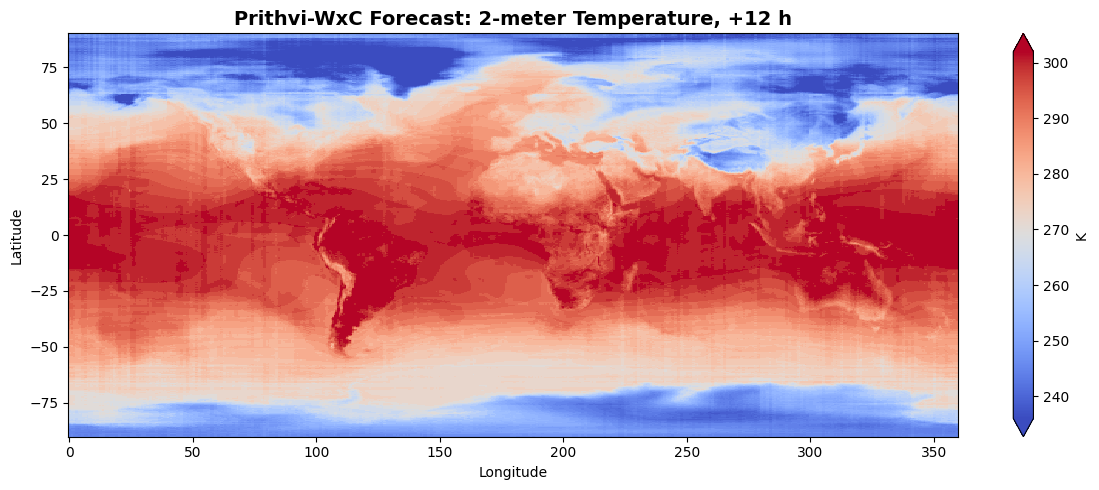

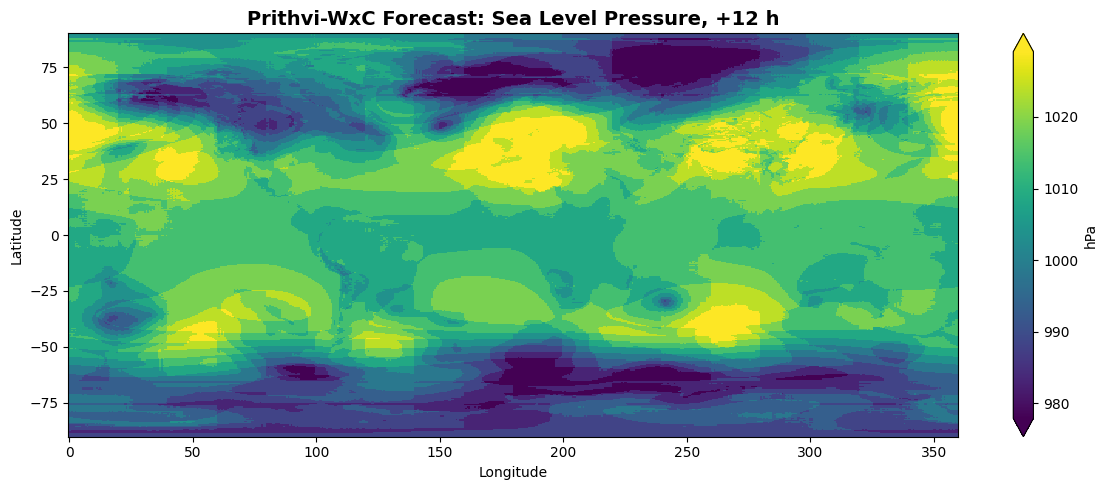

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


def field_from_output(var_name, step=0):
    """Return one forecast field from the rollout output as an xarray DataArray."""
    if var_name not in variable_names:
        available = ", ".join(variable_names)
        raise ValueError(f"{var_name!r} not found. Available variables are: {available}")

    field = out[step, variable_names.index(var_name)].float().cpu().numpy()

    lat = np.linspace(-90, 90, out.shape[-2])
    lon = np.linspace(0, 360, out.shape[-1], endpoint=False)

    return xr.DataArray(
        field,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name=var_name,
    )


def plot_global_field(
    da,
    title,
    units=None,
    cmap="viridis",
    figsize=(12, 5),
    robust=True,
):
    """Create a clean global map using xarray's plotting interface."""
    plt.figure(figsize=figsize)
    da.plot(
        x="lon",
        y="lat",
        cmap=cmap,
        robust=robust,
        cbar_kwargs={"label": units or da.name},
    )
    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.gca().set_aspect("auto")
    plt.tight_layout()
    plt.show()


# 2-meter temperature
t2m = field_from_output("T2M", step=0)
plot_global_field(
    t2m,
    title=f"Prithvi-WxC Forecast: 2-meter Temperature, +{lead_time} h",
    units="K",
    cmap="coolwarm",
)

# Sea level pressure: convert Pa to hPa for readability
slp = field_from_output("SLP", step=0) / 100.0
slp.name = "SLP"
plot_global_field(
    slp,
    title=f"Prithvi-WxC Forecast: Sea Level Pressure, +{lead_time} h",
    units="hPa",
    cmap="viridis",
)


## Notes

- `T2M` is plotted in Kelvin to remain consistent with the native model output.
- `SLP` is converted from Pa to hPa for easier meteorological interpretation.
- The helper functions can be reused for other variables, for example `U10M`, `V10M`, or vertical variables such as `T_level_72.0`.
